# Smart WasteVision — Waste Image Classification (TrashNet)

This notebook builds and compares image classifiers for six waste categories —
**cardboard, glass, metal, paper, plastic, trash** — using the
[TrashNet](https://github.com/garythung/trashnet) `dataset-resized` images.

### Results at a glance

| | |
|---|---|
| **Final model** | ResNet18, pretrained on ImageNet, fine-tuned (`layer4` + classifier) with class-weighted loss |
| **Test accuracy** | 87.86% |
| **Test macro F1** | 88.37% |
| **Test set size** | 379 images (46 misclassified) |
| **Dataset** | 2,527 raw images → 2,524 after removing 3 exact duplicates |

### Pipeline

Dataset loading and duplicate removal → class distribution → stratified 70/15/15 split →
transforms and `Dataset`/`DataLoader` → five experiments (custom CNN, class weighting,
ResNet18 transfer learning, fine-tuning, weighted fine-tuning) → model selection on
validation data → final test evaluation → confusion matrix and error analysis →
single-image prediction.

> Written for Google Colab with a GPU runtime.

## 1. Setup

In [1]:
# Core
import random
import shutil
import hashlib
import zipfile
from pathlib import Path
from collections import Counter

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------------------------
# Fixed class mapping, defined once and used everywhere in the notebook
# ---------------------------------------------------------------------------
CLASS_TO_IDX = {
    "cardboard": 0,
    "glass": 1,
    "metal": 2,
    "paper": 3,
    "plastic": 4,
    "trash": 5,
}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
CLASSES = list(CLASS_TO_IDX.keys())
NUM_CLASSES = len(CLASSES)

# ---------------------------------------------------------------------------
# General configuration
# ---------------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Classes:", CLASS_TO_IDX)

Device: cuda
Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 2. Dataset

In [2]:
# Clone TrashNet (skip if already cloned — safe to re-run this cell).
if not Path("trashnet").exists():
    !git clone https://github.com/garythung/trashnet.git

zip_path = Path("trashnet/data/dataset-resized.zip")
raw_dataset_path = Path("trashnet/data/dataset-resized")

print("ZIP exists:", zip_path.exists())
print("Already extracted:", raw_dataset_path.exists())


ZIP exists: True
Already extracted: False


In [3]:
# Extract only if not already extracted.
if not raw_dataset_path.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(zip_path.parent)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted — skipping.")

print("Dataset exists:", raw_dataset_path.exists())


Dataset extracted successfully!
Dataset exists: True


In [4]:
raw_class_counts = {}

for folder in sorted(raw_dataset_path.iterdir()):
    if folder.is_dir():
        raw_class_counts[folder.name] = len(list(folder.glob("*")))

print("Raw (uncleaned) class counts:")
for class_name, count in raw_class_counts.items():
    print(f"{class_name:10} -> {count} images")
print("Total:", sum(raw_class_counts.values()))


Raw (uncleaned) class counts:
cardboard  -> 403 images
glass      -> 501 images
metal      -> 410 images
paper      -> 594 images
plastic    -> 482 images
trash      -> 137 images
Total: 2527


### 2.1 Duplicate detection and removal

TrashNet contains a few exact duplicate files (the same image saved more than once).
Duplicates are detected by file hash (MD5), and a **clean** copy of the dataset is
built that keeps only the first occurrence of each image. The step is programmatic,
so it stays reproducible even if the raw archive changes.

In [5]:
image_hashes = {}     # hash -> first (kept) path
duplicate_paths = []  # paths to be dropped

for class_name in sorted(raw_class_counts.keys()):
    for image_path in sorted((raw_dataset_path / class_name).glob("*")):
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in image_hashes:
            duplicate_paths.append(image_path)
        else:
            image_hashes[file_hash] = image_path

print("Total raw images   :", sum(raw_class_counts.values()))
print("Duplicate images   :", len(duplicate_paths))
print("Unique images kept :", len(image_hashes))


Total raw images   : 2527
Duplicate images   : 3
Unique images kept : 2524


In [6]:
clean_path = Path("trashnet/clean_dataset")

if clean_path.exists():
    shutil.rmtree(clean_path)

for class_name in raw_class_counts:
    (clean_path / class_name).mkdir(parents=True, exist_ok=True)

duplicate_set = set(str(p) for p in duplicate_paths)

for class_name in sorted(raw_class_counts.keys()):
    for image_path in sorted((raw_dataset_path / class_name).glob("*")):
        if str(image_path) in duplicate_set:
            continue
        shutil.copy(image_path, clean_path / class_name / image_path.name)

clean_class_counts = {
    folder.name: len(list(folder.glob("*")))
    for folder in sorted(clean_path.iterdir()) if folder.is_dir()
}

print("Clean class counts:")
for class_name, count in clean_class_counts.items():
    print(f"{class_name:10} -> {count} images")
print("Total:", sum(clean_class_counts.values()))


Clean class counts:
cardboard  -> 403 images
glass      -> 501 images
metal      -> 409 images
paper      -> 594 images
plastic    -> 480 images
trash      -> 137 images
Total: 2524


## 3. Dataset Analysis

### 3.1 Class distribution

In [7]:
data = []
for class_name in CLASSES:
    class_folder = clean_path / class_name
    for image_path in sorted(class_folder.glob("*")):
        data.append({"image_path": str(image_path), "label": class_name})

df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts().reindex(CLASSES))
df.head()


Total images: 2524

Class distribution:
label
cardboard    403
glass        501
metal        409
paper        594
plastic      480
trash        137
Name: count, dtype: int64


,image_path,label
0,trashnet/clean_dataset/cardboard/cardboard1.jpg,cardboard
1,trashnet/clean_dataset/cardboard/cardboard10.jpg,cardboard
2,trashnet/clean_dataset/cardboard/cardboard100.jpg,cardboard
3,trashnet/clean_dataset/cardboard/cardboard101.jpg,cardboard
4,trashnet/clean_dataset/cardboard/cardboard102.jpg,cardboard


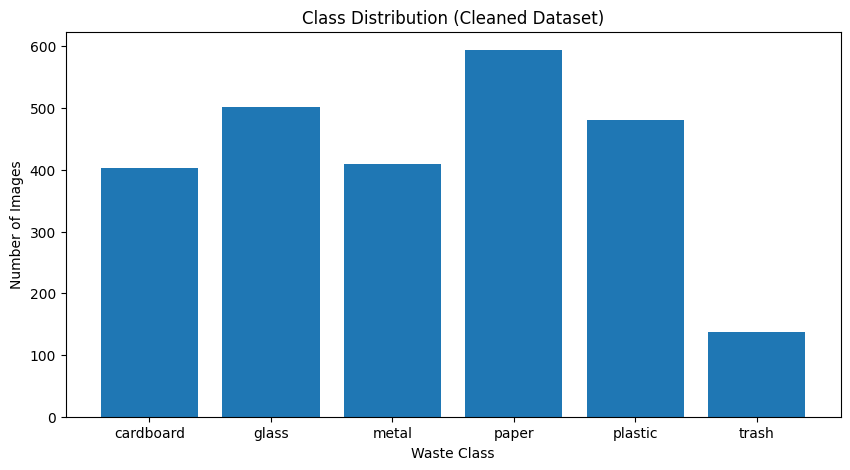

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(df["label"].value_counts().reindex(CLASSES).index,
        df["label"].value_counts().reindex(CLASSES).values)
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Cleaned Dataset)")
plt.show()


The dataset is imbalanced: **trash** has only 137 images, against 594 for **paper**.
This is why class-weighted loss is tested later in the notebook.

### 3.2 Sample images

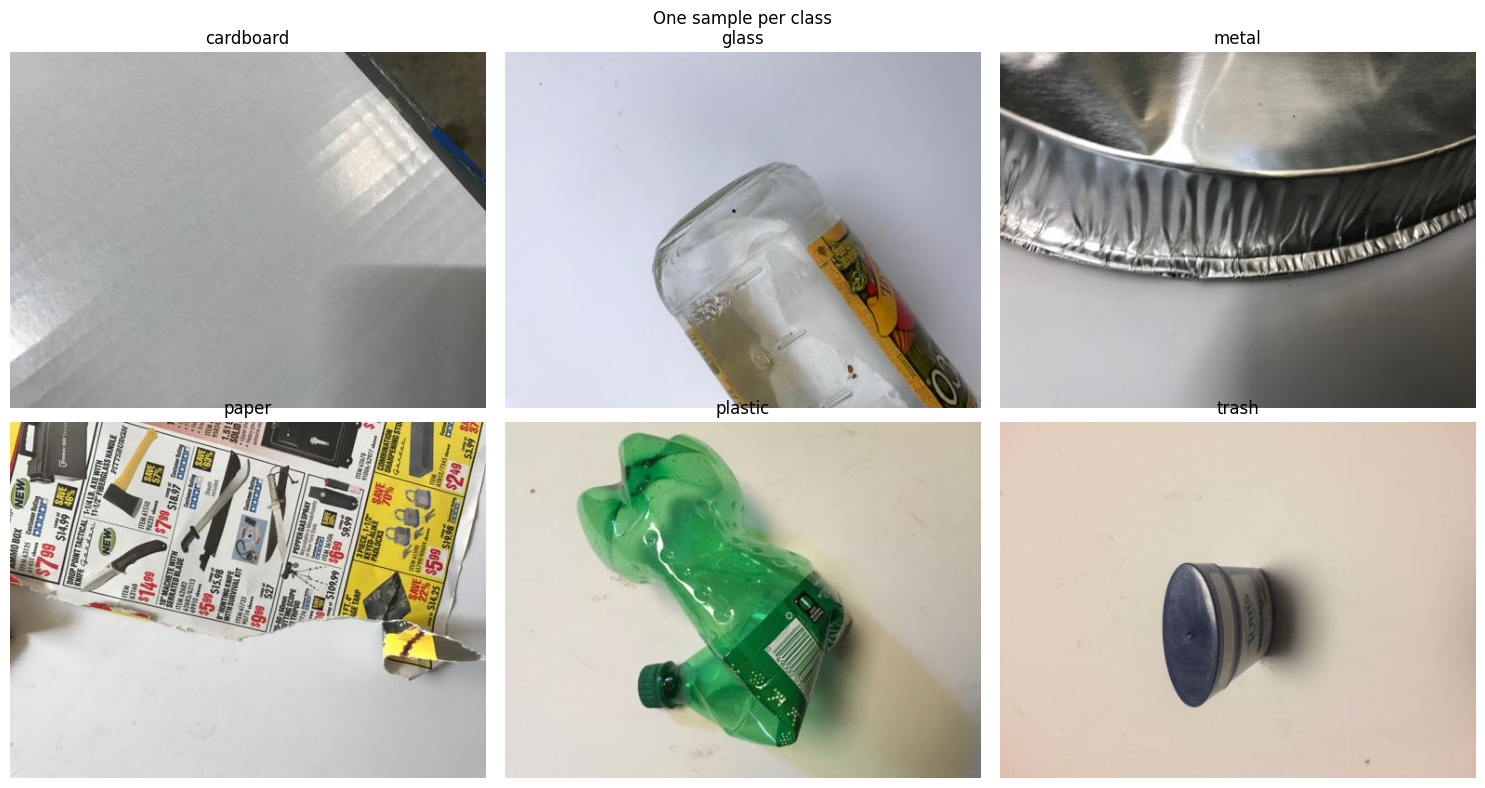

In [9]:
def denormalize(tensor_image):
    """Undo ImageNet normalization for display purposes."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = tensor_image.cpu() * std + mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()


# One random raw (un-augmented) example per class.
plt.figure(figsize=(15, 8))
for i, class_name in enumerate(CLASSES):
    image_path = random.choice(list((clean_path / class_name).glob("*")))
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
plt.suptitle("One sample per class")
plt.tight_layout()
plt.show()


## 4. Data Preparation

### 4.1 Stratified train / validation / test split

70% train, 15% validation, 15% test. The split is stratified on the label so every
subset keeps the original class proportions.

In [10]:
# 70% train, 15% validation, 15% test — stratified on the label so every
# split keeps the original class proportions.
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

# Reset each split's index so `.loc[index, ...]` lookups inside the Dataset
# refer to positions within that split.
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1766
Validation: 379
Test: 379


In [11]:
print("Train distribution:")
print(train_df["label"].value_counts().reindex(CLASSES))

print("\nValidation distribution:")
print(val_df["label"].value_counts().reindex(CLASSES))

print("\nTest distribution:")
print(test_df["label"].value_counts().reindex(CLASSES))


Train distribution:
label
cardboard    282
glass        350
metal        286
paper        416
plastic      336
trash         96
Name: count, dtype: int64

Validation distribution:
label
cardboard    61
glass        75
metal        62
paper        89
plastic      72
trash        20
Name: count, dtype: int64

Test distribution:
label
cardboard    60
glass        76
metal        61
paper        89
plastic      72
trash        21
Name: count, dtype: int64


### 4.2 Transforms

Training images get light augmentation. Validation and test images are only resized
and normalized, using the same ImageNet statistics as training.

In [ ]:
# Training transform: light augmentation + ImageNet normalization.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation / test transform: deterministic resize + the same normalization
# used for training.
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

### 4.3 Dataset and DataLoaders

In [ ]:
class WasteDataset(Dataset):
    """Loads waste images from a DataFrame with `image_path` / `label` columns."""

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label_name = self.dataframe.loc[index, "label"]

        image = Image.open(image_path).convert("RGB")
        label = CLASS_TO_IDX[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label


In [12]:
train_dataset = WasteDataset(train_df, transform=train_transform)
val_dataset = WasteDataset(val_df, transform=val_test_transform)
test_dataset = WasteDataset(test_df, transform=val_test_transform)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

image, label = train_dataset[0]
print("\nSample image shape:", image.shape)
print("Sample label:", label, "->", IDX_TO_CLASS[label])


Train dataset: 1766
Validation dataset: 379
Test dataset: 379

Sample image shape: torch.Size([3, 224, 224])
Sample label: 4 -> plastic


In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)


Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


### 4.4 Augmentation preview

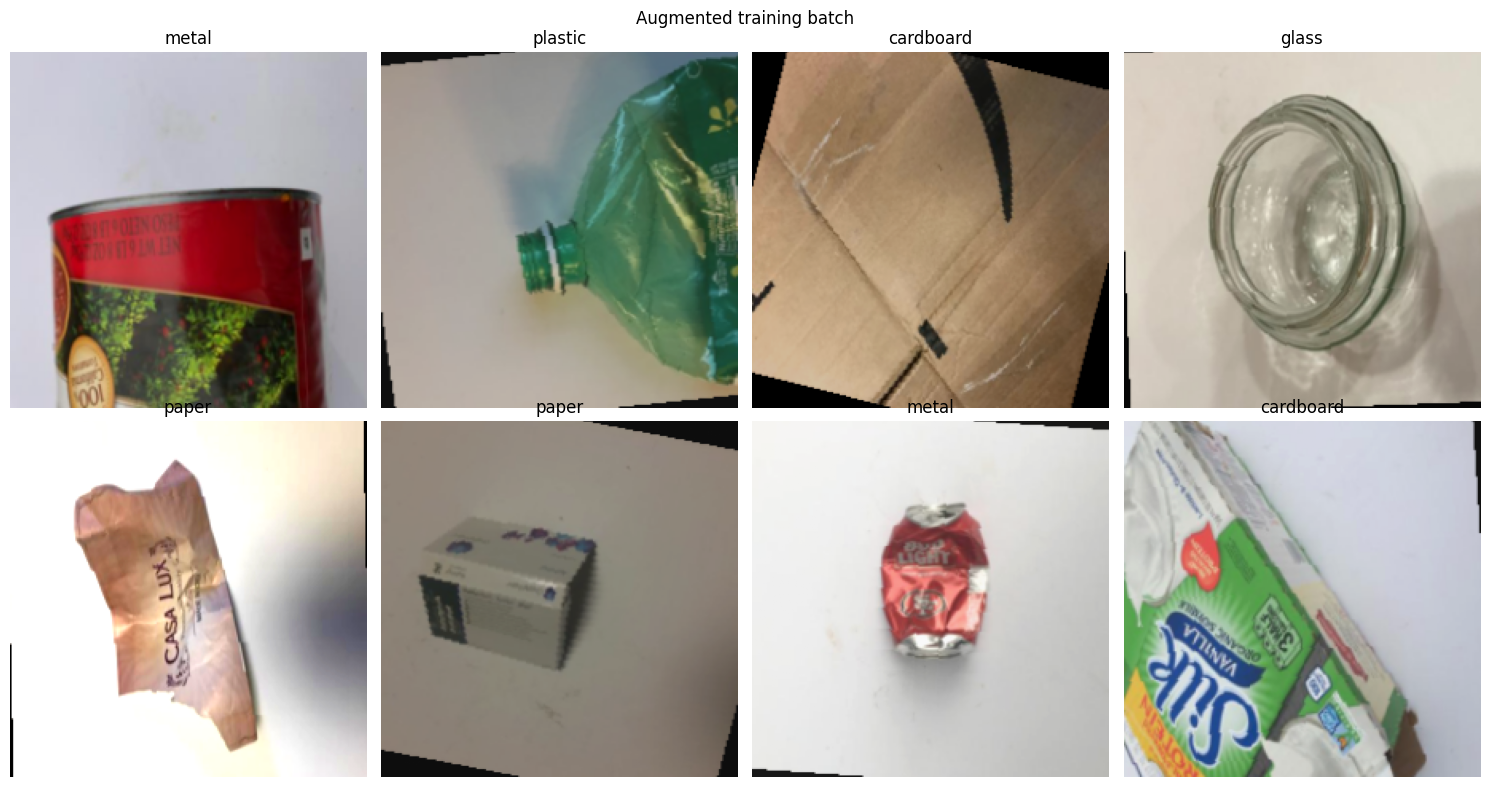

In [14]:
# A batch straight out of the training loader (shows augmentation in action).
images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]))
    plt.title(IDX_TO_CLASS[labels[i].item()])
    plt.axis("off")
plt.suptitle("Augmented training batch")
plt.tight_layout()
plt.show()


## 5. Training and Evaluation Utilities

**Evaluation protocol.** The best checkpoint of every experiment is chosen by
validation accuracy. The **validation set** is also used to compare experiments and
select the final model. The **test set** is reserved for reporting the selected model.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, criterion, optimizer, train_loader, val_loader,
                 device, num_epochs, checkpoint_path):
    """Trains `model` and keeps the checkpoint with the best validation accuracy.

    The best checkpoint is saved to `checkpoint_path` and reloaded into the
    model before it is returned.
    """
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)

        flag = " (best so far -> checkpoint saved)" if improved else ""
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{flag}"
        )

    # Reload the best checkpoint before handing the model back.
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"\nBest validation accuracy: {best_val_acc:.4f} (loaded into model)")

    return model, history


@torch.no_grad()
def evaluate_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(predictions)
        all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

## 6. Experiment 1 — Custom CNN (standard `CrossEntropyLoss`)

A compact CNN with four convolutional blocks (BatchNorm + ReLU + pooling),
`AdaptiveAvgPool2d`, and a dropout-regularized classifier head, trained from scratch.

In [15]:
class WasteCNN(nn.Module):
    """Compact CNN with BatchNorm + Dropout.

    Uses `AdaptiveAvgPool2d` before the classifier head so the flattened
    feature size does not depend on the input resolution.
    """

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Quick shape sanity check.
_sample_model = WasteCNN().to(DEVICE)
images, labels = next(iter(train_loader))
outputs = _sample_model(images.to(DEVICE))
print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
del _sample_model

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 6])


In [16]:
model_standard = WasteCNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion_standard = nn.CrossEntropyLoss()
optimizer_standard = torch.optim.Adam(model_standard.parameters(), lr=LEARNING_RATE)

model_standard, history_standard = train_model(
    model=model_standard,
    criterion=criterion_standard,
    optimizer=optimizer_standard,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    checkpoint_path="best_model_standard.pth",
)


Epoch [1/10] | Train Loss: 1.4772 | Train Acc: 0.4134 | Val Loss: 1.3195 | Val Acc: 0.5092 (best so far -> checkpoint saved)
Epoch [2/10] | Train Loss: 1.3190 | Train Acc: 0.4757 | Val Loss: 1.1904 | Val Acc: 0.5594 (best so far -> checkpoint saved)
Epoch [3/10] | Train Loss: 1.2509 | Train Acc: 0.5074 | Val Loss: 1.0945 | Val Acc: 0.5910 (best so far -> checkpoint saved)
Epoch [4/10] | Train Loss: 1.1989 | Train Acc: 0.5232 | Val Loss: 1.2908 | Val Acc: 0.5040
Epoch [5/10] | Train Loss: 1.1789 | Train Acc: 0.5419 | Val Loss: 1.0652 | Val Acc: 0.6069 (best so far -> checkpoint saved)
Epoch [6/10] | Train Loss: 1.1503 | Train Acc: 0.5600 | Val Loss: 1.4666 | Val Acc: 0.5066
Epoch [7/10] | Train Loss: 1.0924 | Train Acc: 0.5810 | Val Loss: 1.0106 | Val Acc: 0.6253 (best so far -> checkpoint saved)
Epoch [8/10] | Train Loss: 1.0963 | Train Acc: 0.6048 | Val Loss: 1.1077 | Val Acc: 0.5963
Epoch [9/10] | Train Loss: 1.0560 | Train Acc: 0.5957 | Val Loss: 0.9526 | Val Acc: 0.6253
Epoch [10/1

### Validation performance

In [17]:
y_true_val_standard, y_pred_val_standard = evaluate_predictions(
    model_standard, val_loader, DEVICE
)

val_acc_standard = accuracy_score(y_true_val_standard, y_pred_val_standard)
val_f1_macro_standard = f1_score(
    y_true_val_standard, y_pred_val_standard, average="macro"
)

print(f"Validation Accuracy : {val_acc_standard:.4f} ({val_acc_standard * 100:.2f}%)")
print(f"Validation Macro F1  : {val_f1_macro_standard:.4f}")
print()
print(classification_report(
    y_true_val_standard,
    y_pred_val_standard,
    target_names=CLASSES,
    zero_division=0,
))

Validation Accuracy : 0.6385 (63.85%)
Validation Macro F1  : 0.5324

              precision    recall  f1-score   support

   cardboard       0.88      0.72      0.79        61
       glass       0.47      0.87      0.61        75
       metal       0.76      0.26      0.39        62
       paper       0.78      0.79      0.78        89
     plastic       0.60      0.65      0.63        72
       trash       0.00      0.00      0.00        20

    accuracy                           0.64       379
   macro avg       0.58      0.55      0.53       379
weighted avg       0.66      0.64      0.61       379



The baseline reaches 63.85% validation accuracy and 0.5324 macro F1. It never
predicts **trash** correctly (recall 0.00), the smallest class.

## 7. Class Imbalance and Class Weights

Class weights are inversely proportional to class frequency and are calculated **only
from the training split**. Validation and test labels are never used.

In [18]:
train_label_counts = train_df["label"].value_counts().reindex(CLASSES)
total_train = len(train_df)

class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * train_label_counts[c]) for c in CLASSES],
    dtype=torch.float32,
).to(DEVICE)

print("Training class counts:")
print(train_label_counts)

print("\nClass weights:")
for class_name, weight in zip(CLASSES, class_weights):
    print(f"{class_name:10} -> {weight.item():.4f}")

Training class counts:
label
cardboard    282
glass        350
metal        286
paper        416
plastic      336
trash         96
Name: count, dtype: int64

Class weights:
cardboard  -> 1.0437
glass      -> 0.8410
metal      -> 1.0291
paper      -> 0.7075
plastic    -> 0.8760
trash      -> 3.0660


## 8. Experiment 2 — Custom CNN with Class-Weighted Loss

In [19]:
model_weighted = WasteCNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)
optimizer_weighted = torch.optim.Adam(
    model_weighted.parameters(),
    lr=LEARNING_RATE,
)

model_weighted, history_weighted = train_model(
    model=model_weighted,
    criterion=criterion_weighted,
    optimizer=optimizer_weighted,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    checkpoint_path="best_model_weighted.pth",
)

Epoch [1/10] | Train Loss: 1.5517 | Train Acc: 0.3692 | Val Loss: 1.3767 | Val Acc: 0.4301 (best so far -> checkpoint saved)
Epoch [2/10] | Train Loss: 1.3997 | Train Acc: 0.4287 | Val Loss: 1.2313 | Val Acc: 0.4723 (best so far -> checkpoint saved)
Epoch [3/10] | Train Loss: 1.3494 | Train Acc: 0.4694 | Val Loss: 1.1745 | Val Acc: 0.5303 (best so far -> checkpoint saved)
Epoch [4/10] | Train Loss: 1.3123 | Train Acc: 0.4609 | Val Loss: 1.0806 | Val Acc: 0.5620 (best so far -> checkpoint saved)
Epoch [5/10] | Train Loss: 1.2653 | Train Acc: 0.4977 | Val Loss: 1.2094 | Val Acc: 0.5515
Epoch [6/10] | Train Loss: 1.1970 | Train Acc: 0.5294 | Val Loss: 1.1435 | Val Acc: 0.5726 (best so far -> checkpoint saved)
Epoch [7/10] | Train Loss: 1.2444 | Train Acc: 0.4983 | Val Loss: 1.2843 | Val Acc: 0.5172
Epoch [8/10] | Train Loss: 1.1832 | Train Acc: 0.5447 | Val Loss: 1.1666 | Val Acc: 0.5251
Epoch [9/10] | Train Loss: 1.1778 | Train Acc: 0.5391 | Val Loss: 1.1774 | Val Acc: 0.5488
Epoch [10/1

In [20]:
y_true_val_weighted, y_pred_val_weighted = evaluate_predictions(
    model_weighted, val_loader, DEVICE
)

val_acc_weighted = accuracy_score(y_true_val_weighted, y_pred_val_weighted)
val_f1_macro_weighted = f1_score(
    y_true_val_weighted, y_pred_val_weighted, average="macro"
)

print(f"Validation Accuracy : {val_acc_weighted:.4f} ({val_acc_weighted * 100:.2f}%)")
print(f"Validation Macro F1  : {val_f1_macro_weighted:.4f}")
print()
print(classification_report(
    y_true_val_weighted,
    y_pred_val_weighted,
    target_names=CLASSES,
    zero_division=0,
))

Validation Accuracy : 0.5726 (57.26%)
Validation Macro F1  : 0.5435

              precision    recall  f1-score   support

   cardboard       0.80      0.72      0.76        61
       glass       0.49      0.25      0.33        75
       metal       0.55      0.44      0.49        62
       paper       0.57      0.82      0.67        89
     plastic       0.60      0.58      0.59        72
       trash       0.32      0.60      0.42        20

    accuracy                           0.57       379
   macro avg       0.55      0.57      0.54       379
weighted avg       0.58      0.57      0.56       379



Class weighting lifts **trash** recall from 0.00 to 0.60 and macro F1 slightly
(0.5324 → 0.5435), but hurts **glass** recall (0.87 → 0.25) and overall accuracy
(63.85% → 57.26%). The custom CNN is limited by its capacity and data size,
which motivates transfer learning.

## 9. Experiment 3 — ResNet18 Transfer Learning (frozen backbone)

A ResNet18 pretrained on ImageNet. The backbone is frozen and only the new classifier
head (`Dropout` + `Linear`) is trained.

In [21]:
# ---------------------------------------------------------
# Experiment C: Pretrained ResNet18
# ---------------------------------------------------------

resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Replace the original ImageNet classifier
in_features = resnet.fc.in_features

resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

resnet = resnet.to(DEVICE)

print(resnet.fc)

for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in resnet.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in resnet.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=6, bias=True)
)


Trainable parameters: 3078
Total parameters: 11179590


In [22]:
RESNET_EPOCHS = 5

resnet, history_resnet = train_model(
    model=resnet,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=RESNET_EPOCHS,
    checkpoint_path="best_model_resnet18_frozen.pth",
)

Epoch [1/5] | Train Loss: 1.5386 | Train Acc: 0.3907 | Val Loss: 1.1546 | Val Acc: 0.5858 (best so far -> checkpoint saved)
Epoch [2/5] | Train Loss: 1.1488 | Train Acc: 0.5770 | Val Loss: 0.9462 | Val Acc: 0.6438 (best so far -> checkpoint saved)
Epoch [3/5] | Train Loss: 0.9851 | Train Acc: 0.6489 | Val Loss: 0.8737 | Val Acc: 0.6755 (best so far -> checkpoint saved)
Epoch [4/5] | Train Loss: 0.8964 | Train Acc: 0.6818 | Val Loss: 0.8323 | Val Acc: 0.6966 (best so far -> checkpoint saved)
Epoch [5/5] | Train Loss: 0.8836 | Train Acc: 0.6625 | Val Loss: 0.7877 | Val Acc: 0.7203 (best so far -> checkpoint saved)

Best validation accuracy: 0.7203 (loaded into model)


In [23]:
y_true_val_resnet, y_pred_val_resnet = evaluate_predictions(
    resnet,
    val_loader,
    DEVICE
)

val_acc_resnet = accuracy_score(
    y_true_val_resnet,
    y_pred_val_resnet
)

val_f1_resnet = f1_score(
    y_true_val_resnet,
    y_pred_val_resnet,
    average="macro"
)

print(
    f"ResNet18 Validation Accuracy: "
    f"{val_acc_resnet:.4f} ({val_acc_resnet * 100:.2f}%)"
)

print(
    f"ResNet18 Validation Macro F1: "
    f"{val_f1_resnet:.4f}"
)

print()

print(
    classification_report(
        y_true_val_resnet,
        y_pred_val_resnet,
        target_names=CLASSES,
        zero_division=0
    )
)

ResNet18 Validation Accuracy: 0.7203 (72.03%)
ResNet18 Validation Macro F1: 0.6584

              precision    recall  f1-score   support

   cardboard       0.98      0.82      0.89        61
       glass       0.63      0.68      0.65        75
       metal       0.64      0.87      0.73        62
       paper       0.80      0.81      0.80        89
     plastic       0.63      0.60      0.61        72
       trash       0.75      0.15      0.25        20

    accuracy                           0.72       379
   macro avg       0.74      0.65      0.66       379
weighted avg       0.73      0.72      0.71       379



Transfer learning improves validation macro F1 from 0.5324 (custom CNN) to 0.6584,
but **trash** recall is only 0.15 — a frozen backbone is not enough here.

## 10. Experiment 4 — ResNet18 Fine-Tuning

The last residual block (`layer4`) and the classifier are unfrozen and trained with a
lower learning rate (`1e-4`). This raises the number of trainable parameters from
3,078 to 8,396,806 (of 11,179,590).

In [24]:
resnet_ft = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet_ft.fc.in_features

resnet_ft.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

resnet_ft = resnet_ft.to(DEVICE)

for param in resnet_ft.parameters():
    param.requires_grad = False

for param in resnet_ft.layer4.parameters():
    param.requires_grad = True

for param in resnet_ft.fc.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in resnet_ft.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in resnet_ft.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_ft.parameters()),
    lr=1e-4
)

Trainable parameters: 8396806
Total parameters: 11179590


In [25]:
resnet_ft, history_resnet_ft = train_model(
    model=resnet_ft,
    criterion=criterion_ft,
    optimizer=optimizer_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=8,
    checkpoint_path="best_model_resnet18_finetuned.pth",
)

Epoch [1/8] | Train Loss: 1.0481 | Train Acc: 0.6116 | Val Loss: 0.6183 | Val Acc: 0.7731 (best so far -> checkpoint saved)
Epoch [2/8] | Train Loss: 0.4820 | Train Acc: 0.8539 | Val Loss: 0.4813 | Val Acc: 0.8364 (best so far -> checkpoint saved)
Epoch [3/8] | Train Loss: 0.3394 | Train Acc: 0.8901 | Val Loss: 0.3981 | Val Acc: 0.8681 (best so far -> checkpoint saved)
Epoch [4/8] | Train Loss: 0.2426 | Train Acc: 0.9275 | Val Loss: 0.3601 | Val Acc: 0.8628
Epoch [5/8] | Train Loss: 0.1998 | Train Acc: 0.9417 | Val Loss: 0.3305 | Val Acc: 0.8760 (best so far -> checkpoint saved)
Epoch [6/8] | Train Loss: 0.1464 | Train Acc: 0.9541 | Val Loss: 0.3202 | Val Acc: 0.8945 (best so far -> checkpoint saved)
Epoch [7/8] | Train Loss: 0.0889 | Train Acc: 0.9790 | Val Loss: 0.3439 | Val Acc: 0.8813
Epoch [8/8] | Train Loss: 0.0880 | Train Acc: 0.9790 | Val Loss: 0.3142 | Val Acc: 0.9024 (best so far -> checkpoint saved)

Best validation accuracy: 0.9024 (loaded into model)


In [26]:
y_true_val_ft, y_pred_val_ft = evaluate_predictions(
    resnet_ft,
    val_loader,
    DEVICE
)

val_acc_ft = accuracy_score(
    y_true_val_ft,
    y_pred_val_ft
)

val_f1_ft = f1_score(
    y_true_val_ft,
    y_pred_val_ft,
    average="macro"
)

print(
    f"Fine-Tuned ResNet18 Validation Accuracy: "
    f"{val_acc_ft:.4f} ({val_acc_ft * 100:.2f}%)"
)

print(
    f"Fine-Tuned ResNet18 Validation Macro F1: "
    f"{val_f1_ft:.4f}"
)

print()

print(
    classification_report(
        y_true_val_ft,
        y_pred_val_ft,
        target_names=CLASSES,
        zero_division=0
    )
)

Fine-Tuned ResNet18 Validation Accuracy: 0.9024 (90.24%)
Fine-Tuned ResNet18 Validation Macro F1: 0.8816

              precision    recall  f1-score   support

   cardboard       0.98      0.90      0.94        61
       glass       0.90      0.88      0.89        75
       metal       0.87      0.94      0.90        62
       paper       0.91      0.98      0.94        89
     plastic       0.88      0.88      0.88        72
       trash       0.87      0.65      0.74        20

    accuracy                           0.90       379
   macro avg       0.90      0.87      0.88       379
weighted avg       0.90      0.90      0.90       379



## 11. Experiment 5 — Class-Weighted Fine-Tuned ResNet18

Same setup as Experiment 4, but trained with the class-weighted loss from Section 7.

In [27]:
# Fresh pretrained ResNet18
resnet_wt = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

in_features = resnet_wt.fc.in_features

resnet_wt.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

resnet_wt = resnet_wt.to(DEVICE)

# Freeze everything
for param in resnet_wt.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in resnet_wt.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in resnet_wt.fc.parameters():
    param.requires_grad = True


# Weighted Cross Entropy (class_weights computed in Section 7)
criterion_wt = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer_wt = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_wt.parameters()),
    lr=1e-4
)

print("Model ready.")

Model ready.


In [28]:
resnet_wt, history_resnet_wt = train_model(
    model=resnet_wt,
    criterion=criterion_wt,
    optimizer=optimizer_wt,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=8,
    checkpoint_path="best_model_resnet18_weighted_finetuned.pth",
)

Epoch [1/8] | Train Loss: 1.1410 | Train Acc: 0.5419 | Val Loss: 0.6405 | Val Acc: 0.7942 (best so far -> checkpoint saved)
Epoch [2/8] | Train Loss: 0.5513 | Train Acc: 0.8120 | Val Loss: 0.5007 | Val Acc: 0.8259 (best so far -> checkpoint saved)
Epoch [3/8] | Train Loss: 0.3775 | Train Acc: 0.8669 | Val Loss: 0.4163 | Val Acc: 0.8681 (best so far -> checkpoint saved)
Epoch [4/8] | Train Loss: 0.2631 | Train Acc: 0.9134 | Val Loss: 0.4187 | Val Acc: 0.8654
Epoch [5/8] | Train Loss: 0.2016 | Train Acc: 0.9349 | Val Loss: 0.3638 | Val Acc: 0.8734 (best so far -> checkpoint saved)
Epoch [6/8] | Train Loss: 0.1482 | Train Acc: 0.9638 | Val Loss: 0.3661 | Val Acc: 0.8734
Epoch [7/8] | Train Loss: 0.1211 | Train Acc: 0.9677 | Val Loss: 0.3353 | Val Acc: 0.8918 (best so far -> checkpoint saved)
Epoch [8/8] | Train Loss: 0.0976 | Train Acc: 0.9728 | Val Loss: 0.3915 | Val Acc: 0.8760

Best validation accuracy: 0.8918 (loaded into model)


In [29]:
y_true_val_wt, y_pred_val_wt = evaluate_predictions(
    resnet_wt,
    val_loader,
    DEVICE
)

val_acc_wt = accuracy_score(
    y_true_val_wt,
    y_pred_val_wt
)

val_f1_wt = f1_score(
    y_true_val_wt,
    y_pred_val_wt,
    average="macro"
)

print(
    f"Weighted Fine-Tuned ResNet18 Validation Accuracy: "
    f"{val_acc_wt:.4f} ({val_acc_wt * 100:.2f}%)"
)

print(
    f"Weighted Fine-Tuned ResNet18 Validation Macro F1: "
    f"{val_f1_wt:.4f}"
)

print()

print(
    classification_report(
        y_true_val_wt,
        y_pred_val_wt,
        target_names=CLASSES,
        zero_division=0
    )
)

Weighted Fine-Tuned ResNet18 Validation Accuracy: 0.8918 (89.18%)
Weighted Fine-Tuned ResNet18 Validation Macro F1: 0.8862

              precision    recall  f1-score   support

   cardboard       1.00      0.93      0.97        61
       glass       0.89      0.84      0.86        75
       metal       0.82      0.94      0.87        62
       paper       0.93      0.93      0.93        89
     plastic       0.84      0.85      0.84        72
       trash       0.89      0.80      0.84        20

    accuracy                           0.89       379
   macro avg       0.89      0.88      0.89       379
weighted avg       0.89      0.89      0.89       379



## 12. Model Comparison and Selection

All experiments are compared on the **validation set** (values copied from the
outputs above; each configuration was trained once with seed 42).

| # | Model | Val accuracy | Val macro F1 | Trash recall (val) |
|---|---|---|---|---|
| 1 | Custom CNN, standard loss | 63.85% | 0.5324 | 0.00 |
| 2 | Custom CNN, class-weighted loss | 57.26% | 0.5435 | 0.60 |
| 3 | ResNet18, frozen backbone | 72.03% | 0.6584 | 0.15 |
| 4 | ResNet18, fine-tuned | 90.24% | 0.8816 | 0.65 |
| 5 | ResNet18, fine-tuned + class-weighted | 89.18% | 0.8862 | 0.80 |

**Selected model: Experiment 5** — it has the highest validation macro F1, the metric
that matters for an imbalanced dataset. Fine-tuning gives the largest gain by far
(macro F1 0.66 → 0.88). The difference between Experiments 4 and 5 is small
(0.8816 vs 0.8862 macro F1, and Experiment 4 has slightly higher accuracy), so the
main benefit of class weighting is better recall on the small **trash** class
(0.65 → 0.80), not a large overall gain.

## 13. Final Test Evaluation

The selected model (Experiment 5) is evaluated on the held-out test set.

In [30]:
# ============================================
# FINAL TEST EVALUATION
# Weighted Fine-Tuned ResNet18
# ============================================

y_true_test, y_pred_test = evaluate_predictions(
    resnet_wt,
    test_loader,
    DEVICE
)

test_acc = accuracy_score(
    y_true_test,
    y_pred_test
)

test_f1 = f1_score(
    y_true_test,
    y_pred_test,
    average="macro"
)

print(f"Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Final Test Macro F1: {test_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=CLASSES,
        zero_division=0
    )
)

Final Test Accuracy: 0.8786 (87.86%)
Final Test Macro F1: 0.8837

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.96      0.90      0.93        60
       glass       0.95      0.74      0.83        76
       metal       0.73      0.95      0.83        61
       paper       0.92      0.92      0.92        89
     plastic       0.84      0.89      0.86        72
       trash       0.95      0.90      0.93        21

    accuracy                           0.88       379
   macro avg       0.89      0.88      0.88       379
weighted avg       0.89      0.88      0.88       379



## 14. Confusion Matrix

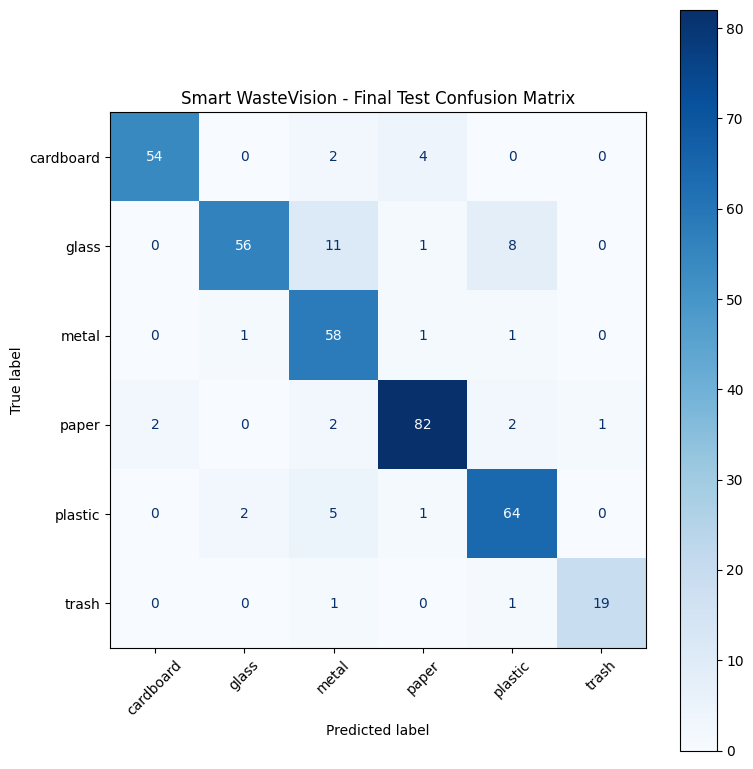

In [31]:
cm = confusion_matrix(
    y_true_test,
    y_pred_test
)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Smart WasteVision - Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 15. Error Analysis

### 15.1 Most common wrong predictions

In [32]:
print("Most common wrong predictions:\n")

wrong_pairs = Counter()

for actual, predicted in zip(y_true_test, y_pred_test):

    if actual != predicted:

        pair = (
            CLASSES[actual],
            CLASSES[predicted]
        )

        wrong_pairs[pair] += 1


for (actual, predicted), count in wrong_pairs.most_common():

    print(
        f"Actual: {actual:10s} → "
        f"Predicted: {predicted:10s} = {count}"
    )

Most common wrong predictions:

Actual: glass      → Predicted: metal      = 11
Actual: glass      → Predicted: plastic    = 8
Actual: plastic    → Predicted: metal      = 5
Actual: cardboard  → Predicted: paper      = 4
Actual: paper      → Predicted: cardboard  = 2
Actual: cardboard  → Predicted: metal      = 2
Actual: paper      → Predicted: metal      = 2
Actual: plastic    → Predicted: glass      = 2
Actual: paper      → Predicted: plastic    = 2
Actual: trash      → Predicted: metal      = 1
Actual: metal      → Predicted: paper      = 1
Actual: paper      → Predicted: trash      = 1
Actual: metal      → Predicted: glass      = 1
Actual: trash      → Predicted: plastic    = 1
Actual: metal      → Predicted: plastic    = 1
Actual: plastic    → Predicted: paper      = 1
Actual: glass      → Predicted: paper      = 1


### 15.2 Misclassified test images

In [33]:
wrong_images = []
wrong_labels = []
wrong_preds = []

resnet_wt.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = resnet_wt(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                wrong_images.append(images[i].cpu())
                wrong_labels.append(labels[i].cpu().item())
                wrong_preds.append(preds[i].cpu().item())

print("Total wrong predictions:", len(wrong_images))

Total wrong predictions: 46


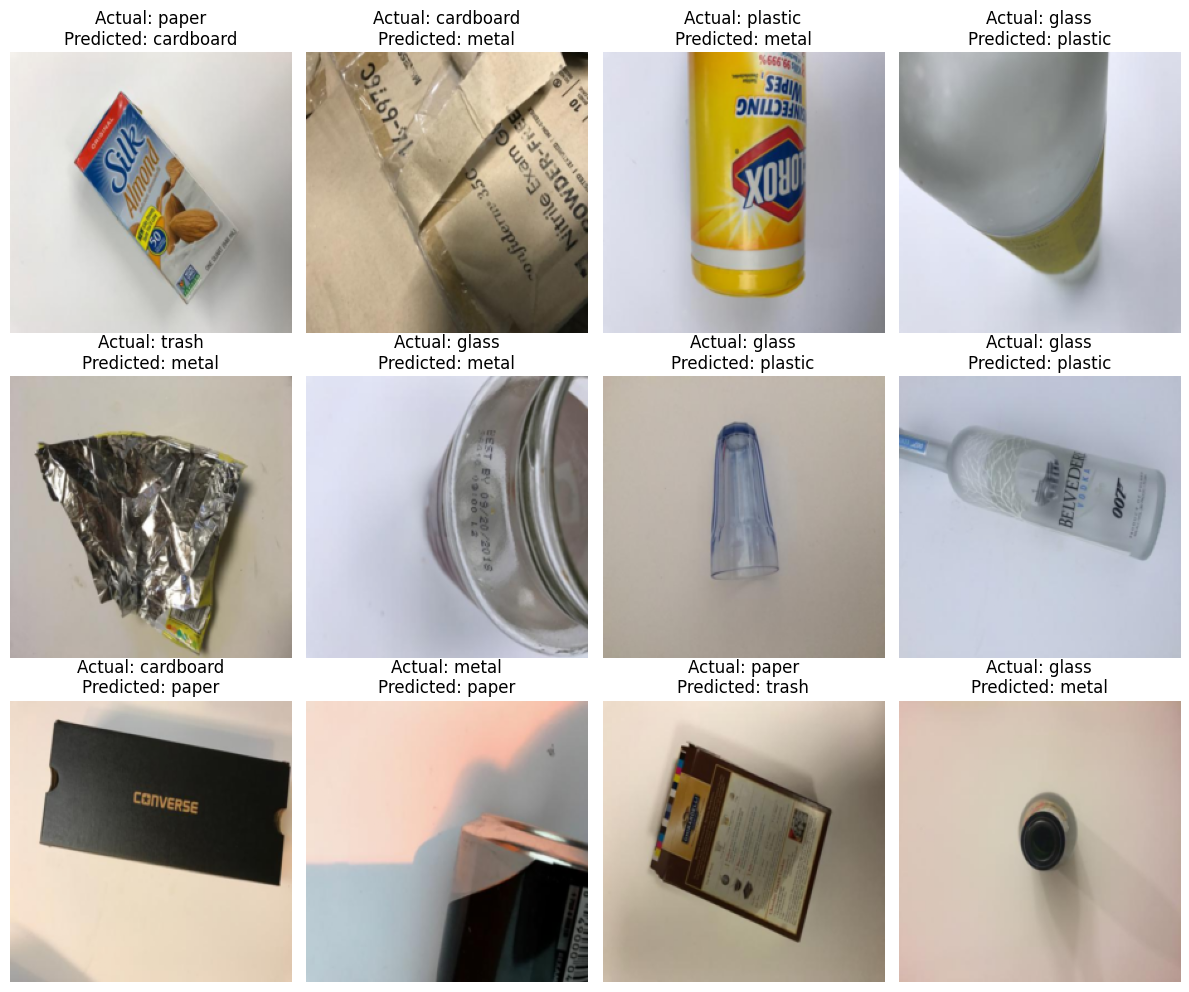

In [34]:
# Show the first 12 wrong predictions (in test-loader order)

plt.figure(figsize=(12, 10))

for i in range(min(12, len(wrong_images))):

    image = wrong_images[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize(image))

    actual = CLASSES[wrong_labels[i]]
    predicted = CLASSES[wrong_preds[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 15.3 Observations

- Of the 46 errors, **19 are glass predicted as metal (11) or plastic (8)**. Glass has
  the lowest recall (0.74).
- **Metal** has the lowest precision (0.73) because other classes are predicted as
  metal: glass (11), plastic (5), cardboard (2), paper (2) and trash (1).
- **Cardboard and paper** are confused in both directions (4 + 2 errors).
- In the 12 images shown above, the errors involve transparent glass objects predicted
  as plastic or metal, crumpled foil labelled trash predicted as metal, a black
  cardboard box predicted as paper, and a printed carton labelled paper predicted as
  cardboard. These are observations from 12 of the 46 errors, not a full analysis.

The dominant pattern is confusion between visually similar materials.

## 16. Single-Image Prediction

`predict_image` returns the predicted class and confidence for one image and shows
the class probabilities.

In [ ]:
def predict_image(
    model,
    image_path,
    transform,
    device,
    idx_to_class=IDX_TO_CLASS,
):
    """Predict a single waste image and return (class_name, confidence)."""
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_idx = int(torch.argmax(probabilities).item())
        confidence = float(probabilities[predicted_idx].item())

    predicted_class = idx_to_class[predicted_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(
        f"Predicted: {predicted_class} "
        f"({confidence * 100:.1f}%)"
    )
    plt.axis("off")
    plt.show()

    print("Class probabilities:")
    for i, class_name in enumerate(CLASSES):
        print(f"{class_name:10} -> {probabilities[i].item():.4f}")

    return predicted_class, confidence

In [ ]:
# Example: predict one image from the test set with the final model.
demo_image_path = test_df.sample(1, random_state=SEED)["image_path"].iloc[0]

predicted_class, confidence = predict_image(
    resnet_wt,
    demo_image_path,
    val_test_transform,
    DEVICE,
)

print(f"\nPredicted class: {predicted_class} | Confidence: {confidence:.4f}")

## 17. Conclusion

**Result.** A class-weighted, fine-tuned ResNet18 reaches **87.86% test accuracy** and
**88.37% macro F1** on 379 held-out images. Per-class F1 ranges from 0.83 (glass, metal)
to 0.93 (cardboard, trash).

**What made the difference.**
- Transfer learning from ImageNet and fine-tuning `layer4` gave the biggest improvement
  (validation macro F1: 0.53 custom CNN → 0.66 frozen ResNet18 → 0.88 fine-tuned).
- Class weighting mainly helped the small **trash** class (validation recall 0.65 → 0.80).

**Limitations.**
- The remaining errors are mostly visually similar materials, especially glass being
  predicted as metal or plastic.
- Each configuration was trained once on a single split, and the test set is small
  (e.g. 21 trash images), so differences of a point or two should not be over-interpreted.
- The example images shown use plain backgrounds; performance on cluttered real-world
  photos has not been tested.

**Skills demonstrated:** data cleaning (hash-based duplicate removal), stratified
splitting, image augmentation, custom `Dataset`/`DataLoader`, a CNN built from scratch,
transfer learning and fine-tuning, handling class imbalance, validation-based model
selection, and confusion-matrix / error analysis.